In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
path = '../Data/Economic_data'
df_GAS_NATIONAL = pd.read_csv(f'{path}/Gas_prices_national.csv', parse_dates=['observation_date'])
df_GAS_WI = pd.read_csv(f'{path}/Gas_prices_midwest.csv', parse_dates=['observation_date'])
df_GAS_TX = pd.read_csv(f'{path}/Gas_prices_gulf_coast.csv', parse_dates=['observation_date'])
df_GAS_CA = pd.read_csv(f'{path}/Gas_prices_west_coast.csv', parse_dates=['observation_date'])

In [3]:
df_GAS_NATIONAL = df_GAS_NATIONAL.rename(columns={'observation_date': 'date', 'APU000074714': 'gas_NATIONAL'})
df_GAS_WI = df_GAS_WI.rename(columns={'observation_date': 'date', 'GASREGMWW': 'gas_WI'})
df_GAS_TX = df_GAS_TX.rename(columns={'observation_date': 'date', 'GASREGCOVGCW': 'gas_TX'})
df_GAS_CA = df_GAS_CA.rename(columns={'observation_date': 'date', 'GASREGWCW': 'gas_CA'})

In [4]:
df_GAS_ALL = df_GAS_WI.merge(df_GAS_TX, on='date')
df_GAS_ALL = df_GAS_ALL.merge(df_GAS_CA, on='date')

df_GAS_ALL['gas_ALL_avg'] = df_GAS_ALL[['gas_WI', 'gas_TX', 'gas_CA']].mean(axis=1).round(3)

df_GAS_ALL.head()

,date,gas_WI,gas_TX,gas_CA,gas_ALL_avg
0,2011-01-03,3.064,2.933,3.236,3.078
1,2011-01-10,3.084,2.944,3.261,3.096
2,2011-01-17,3.089,2.961,3.286,3.112
3,2011-01-24,3.087,2.975,3.293,3.118
4,2011-01-31,3.086,2.948,3.299,3.111


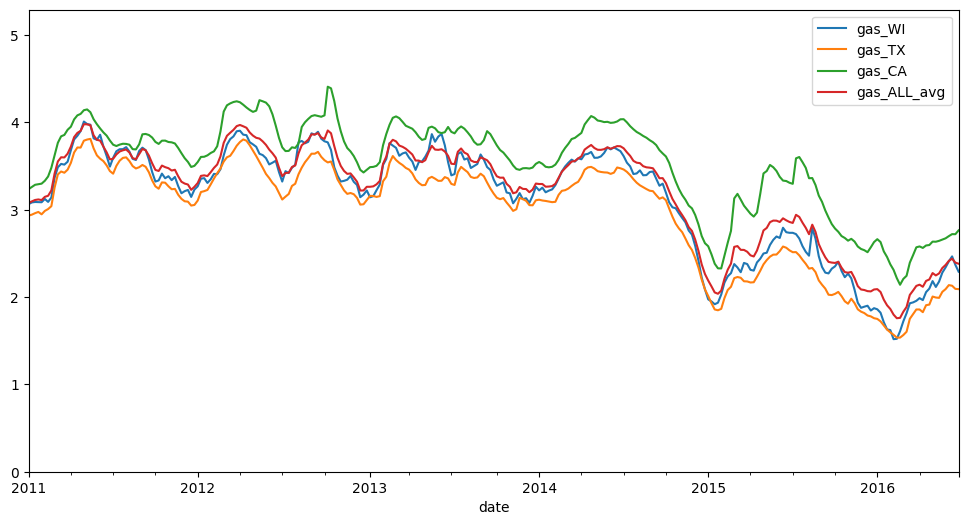

In [5]:
ax = df_GAS_ALL.plot(x='date', figsize=(12,6))

plt.autoscale(enable=True, tight=True)
ax.set_ylim(bottom=0, top=df_GAS_ALL['gas_CA'].max() * 1.2)
plt.show()

In [6]:
df_GAS_ALL.to_csv('../Data/Derived_data/GAS_ALL.csv', index=False)